In [1]:
import pandas as pd
import json
import numpy as np
import requests
from tqdm.auto import tqdm
from config import URL, TOKEN

import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [ ]:
headers = {
    "Authorization": f"Bearer {TOKEN}"
}

itemCount = np.inf
data = {"entries": []}

offset = 0
steps = 1000

progress = None

while len(data["entries"]) < itemCount:

    response = requests.get(
        f"{URL}person/client/query?sort=personNr&limit={steps}&skip={offset}",
        headers=headers,
        verify=False
    )

    if response.status_code == 200:
        responseData = response.json()

        entries = responseData["entries"]

        # Total becomes known after first request
        if progress is None:
            itemCount = responseData["pagingInfo"]["itemCount"]

            progress = tqdm(
                total=itemCount,
                desc="Downloading clients",
                unit="entries"
            )

        data["entries"].extend(entries)

        # Advance by actual number received
        progress.update(len(entries))

        offset += steps

    else:
        print(response.json())
        break

if progress is not None:
    progress.close()

In [3]:
exceptions = [
	"metadata",
	"locality",
	"postalcode",
	"contactoptions",
	"personFullName",
	"personFullNameNoTitle",
	"tenantid",
	"persontype",
	"adresse",
	"mailAddressing",
	"socialInsuranceNumber",
	"comments",
	"givenName",
	"familyName",
	"primaryEmailAddress",
	'addresses',
	'primaryPhoneNumber',
	'address',
	'residentialAddress',
	'address',
	'geoLocation',
	'billingAddress',
	'serviceAddress',
	'legalAddress',
	'businessAddress',
	'emailAddresses',
	'phoneNumbers',
	'personFullNameNoTitle',
	'personFullName',
	'mailAddressing',
	'postalAddress',
	'contractualAddressing',
	'caatsDateOfBirth',
	'gender',
	'locations',
	'bankDetails',
	'personStatus',
	"chapterId",
	"language",
	"ordinal",
	"sectionId",
	"academicTitlePrefix",
	"personNr",
	"content",
	"consecutiveNumber",
	'Klient:innen_Empfohlen_Ja',
	'Klient:innen_Erstrkontakt_erfassen_Ja',
	'Klient:innen_Bew_Ein_Ja',
	'abrech-akonto',
	'abrech-buerge-hinterlegt',
	'pers-visite-keine',
	'medizinische-delegation-hochgeladen',
	'medizinische-delegation-nicht-notwendig',
	'Klient:innen_Medizinische_Delegation_Ja',
	'pflegerische-delegation-hochgeladen',
	'pflegerische-delegation-nicht-notwendig',
	'Klient:innen_Pflegerische_Delegation_JA',
	"admin-beruf",
	'pflegevisite-letzte-date',
	'pflegevisite-letzte-dgkp',
	'pflegerisch-person',
	'erstkontakt-bemerkung',
	"admin-kooperationspartner",
	"orgRef",
	"admin.gsber",
	"admin-bundesland"
]

exceptions = [x.lower() for x in exceptions]

In [4]:
def extractStatement(statement):
    field = {}
    if statement["statementId"].lower() in exceptions:
        return field

    match statement["answerScheme"]:
        case 1:
            field[statement["statementId"]] = statement["answerValue"]["displayText"]
        case 2:
            #do nothing
            field = {}
        case 3:
            field[statement["statementId"]] = statement["answerYesno"] == 2
        case 4:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False

        case 5:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False
        case 8:
            if "answerDateTime" in statement.keys():
                if "userLocalTime" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["userLocalTime"]
                elif "timeUtc" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["timeUtc"]
        case _:
            print(f'Found statement: {statement["answerScheme"]} - {statement["statementId"]} -  {statement}')


    return field
        

def returnEntry(entry):
    keys = entry.keys()
    finalFields = {}
    if "statementId" in keys:
        finalFields = finalFields | extractStatement(entry)
    else:
        for key in keys:
            
            if key.lower() in exceptions:
                continue
            
            typing = type(entry[key]).__name__
            match typing:
                case "str":
                    finalFields[key] = entry[key]
                    
                case "int":
                    finalFields[key] = entry[key]

                case "bool":
                    finalFields[key] = entry[key]

                case "float":
                    finalFields[key] = entry[key]
                    
                case "dict":
                    if "displayText" in entry[key].keys():
                        finalFields[key] = entry[key]["displayText"]
                        continue
                    else:
                        finalFields = finalFields | returnEntry(entry[key])
                    
                case "list":
                    for item in entry[key]:
                        if type(item).__name__ == "dict":
                            finalFields = finalFields | returnEntry(item)
                        

                case _:
                    print(typing)


    
    return finalFields

In [5]:
totalData = []

if data["entries"] is not None:
    for entry in data["entries"]:
        test = returnEntry(entry)
        totalData.append(test)
        
df = pd.DataFrame(totalData)
df

,nationalityId,genderId,id,dateOfBirth,admin-zone,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,...,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,haushalt-2pers-bewilligte-pflegestufe,akonto-datum,adrech-andere,verbandswechsel,schlaf-nacht-aufsteg-betreuung-ja-kommentar,generalPractitioner,avatarFileId,abrech-keinfeiertagszuschlag
0,,M,24eee8b3-9688-7a37-0e55-92b919444684,19360503,Zone 4,Sonstige,True,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,M,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,19681115,Zone 4,Sonstige,True,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,,M,dbe1dce3-4b4c-2825-5340-8bf455359434,19320721,Zone 5,Sonstige,True,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,,F,c2537299-8715-16db-6207-baf55bd7c252,19401204,Zone 1,Sonstige,True,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,,M,d071a0c8-c46a-36e0-2387-5cf8faa28bc8,19351009,Zone 2,Sonstige,True,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11080,,NaN,d39aaa75-3527-4b9a-ac6d-902c95a4f519,19390302,NaN,Premium,True,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
11081,,NaN,df452493-f7e9-4253-80c5-349f30574dfb,19401026,Zone 5,Premium,True,False,False,False,...,False,True,keine Pflegestufe,NaN,NaN,NaN,NaN,,NaN,NaN
11082,,NaN,7c677644-bda2-408d-85ec-3f862c7f6d75,19501110,Zone 41,Diplomierte Fachkraft,True,False,False,False,...,NaN,NaN,NaN,NaN,"Wolf, Elisabeth",NaN,NaN,,NaN,NaN
11083,,NaN,46f1f1da-5cda-4325-b57e-f65e7dcade04,19421021,Zone 2,Klassik,True,False,False,False,...,False,True,NaN,NaN,NaN,NaN,NaN,,NaN,NaN


In [6]:
for col in df.columns:
    non_null = df[col].dropna()

    if len(non_null) > 0 and non_null.isin([True, False]).all():
        df[col] = df[col].fillna(False).astype(bool)

bool_cols = df.select_dtypes(include=["bool", "boolean"]).columns

df[bool_cols] = df[bool_cols].fillna(False)


df = df.replace(r'^\s*$', np.nan, regex=True)

df

C:\Users\npozdena\AppData\Local\Temp\ipykernel_4376\826111804.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(bool)
C:\Users\npozdena\AppData\Local\Temp\ipykernel_4376\826111804.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(bool)
C:\Users\npozdena\AppData\Local\Temp\ipykernel_4376\826111804.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To

,nationalityId,genderId,id,dateOfBirth,admin-zone,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,...,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,haushalt-2pers-bewilligte-pflegestufe,akonto-datum,adrech-andere,verbandswechsel,schlaf-nacht-aufsteg-betreuung-ja-kommentar,generalPractitioner,avatarFileId,abrech-keinfeiertagszuschlag
0,NaN,M,24eee8b3-9688-7a37-0e55-92b919444684,19360503,Zone 4,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,False,NaN,NaN,NaN,False
1,NaN,M,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,19681115,Zone 4,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,False,NaN,NaN,NaN,False
2,NaN,M,dbe1dce3-4b4c-2825-5340-8bf455359434,19320721,Zone 5,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,False,NaN,NaN,NaN,False
3,NaN,F,c2537299-8715-16db-6207-baf55bd7c252,19401204,Zone 1,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,False,NaN,NaN,NaN,False
4,NaN,M,d071a0c8-c46a-36e0-2387-5cf8faa28bc8,19351009,Zone 2,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,False,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11080,NaN,NaN,d39aaa75-3527-4b9a-ac6d-902c95a4f519,19390302,NaN,Premium,True,False,False,False,...,False,False,NaN,NaN,NaN,False,NaN,NaN,NaN,False
11081,NaN,NaN,df452493-f7e9-4253-80c5-349f30574dfb,19401026,Zone 5,Premium,True,False,False,False,...,False,True,keine Pflegestufe,NaN,NaN,False,NaN,NaN,NaN,False
11082,NaN,NaN,7c677644-bda2-408d-85ec-3f862c7f6d75,19501110,Zone 41,Diplomierte Fachkraft,True,False,False,False,...,False,False,NaN,NaN,"Wolf, Elisabeth",False,NaN,NaN,NaN,False
11083,NaN,NaN,46f1f1da-5cda-4325-b57e-f65e7dcade04,19421021,Zone 2,Klassik,True,False,False,False,...,False,True,NaN,NaN,NaN,False,NaN,NaN,NaN,False


In [7]:
df.isna().sum()[df.isna().sum() > 0]

nationalityId                                  11085
genderId                                         144
dateOfBirth                                       17
admin-zone                                      1772
admin-packet                                    1108
levelOfCare                                     4346
vertragsdatum                                    821
betreuungsbeginn                                 502
ausgeschieden-am                                1471
pers-koerper-groesse                            3158
pers-koerper-gewicht                            3008
entfernung-familie                              6878
mobiler-dienst-haeufigkeit                      8744
ausgeschieden-grund                             9305
schlaf-nacht-aufsteh-haeufigkeit                6070
pflegestufe-bemessung                           8740
empfehlung-bemerkung                            9353
pflegestufe-doku                               10191
pflegevisite-planned-date                     

In [8]:
df = df.dropna(axis=1, thresh=int(0.9 * len(df)))

df = df.dropna()

In [9]:
df

,genderId,id,dateOfBirth,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,...,tiere-versorgen,unterstuetzung-haushaltsbuch,hautdefekte,hilfsmittel-wechseldruckmatratze,Klient:innen_Haushalt_Sonstiges_Ja,unterstuetzung-pflanzen-tiere,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,verbandswechsel,abrech-keinfeiertagszuschlag
1,M,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,19681115,Sonstige,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,F,c2537299-8715-16db-6207-baf55bd7c252,19401204,Sonstige,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
6,F,38a4e275-8903-a1db-35c2-082145df26e0,19381224,Sonstige,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
7,F,a6f7f6bb-9872-85ea-c50d-764e8c8311eb,19431104,Sonstige,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
20,M,c61c7939-97a4-e2eb-d7e4-cca94eb88e79,19440303,Sonstige,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10938,M,74b0ec81-6225-2ce0-ea79-05e47e87fea0,19450528,Basis,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10939,F,8ea7fb29-0489-d666-bc37-31d6fb77b3ee,19420714,Premium,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10940,F,9d47c510-011e-b656-a901-a7ef20dfe793,19870101,Diplomierte Fachkraft,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10941,kA,98b2268a-a10f-f8f0-c2cc-76895f99eb8c,19380508,CD Perle,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
min_unique = 2
max_unique = len(df) * 0.9


n_unique = df.nunique()

cols_to_drop = n_unique[
    (n_unique < min_unique) | (n_unique > max_unique)
].index

cols_to_drop = [col for col in cols_to_drop if col != "id"]

df = df.drop(columns=cols_to_drop)

df

,genderId,id,dateOfBirth,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,...,qual-dgkp,qual-de-basis,qual-de-einfach,qual-de-gehoben,Klient:innen_Diagnose_Sonstiges_Ja,mobiler-dienst-weiterhin-nein,mobiler-dienst-weiterhin-ja,tiere-versorgen,unterstuetzung-haushaltsbuch,haushalt-2pers-betreuung-ja
1,M,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,19681115,Sonstige,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
3,F,c2537299-8715-16db-6207-baf55bd7c252,19401204,Sonstige,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
6,F,38a4e275-8903-a1db-35c2-082145df26e0,19381224,Sonstige,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
7,F,a6f7f6bb-9872-85ea-c50d-764e8c8311eb,19431104,Sonstige,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
20,M,c61c7939-97a4-e2eb-d7e4-cca94eb88e79,19440303,Sonstige,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10938,M,74b0ec81-6225-2ce0-ea79-05e47e87fea0,19450528,Basis,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
10939,F,8ea7fb29-0489-d666-bc37-31d6fb77b3ee,19420714,Premium,True,False,False,True,False,False,...,False,False,True,False,False,True,False,False,False,False
10940,F,9d47c510-011e-b656-a901-a7ef20dfe793,19870101,Diplomierte Fachkraft,True,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
10941,kA,98b2268a-a10f-f8f0-c2cc-76895f99eb8c,19380508,CD Perle,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False


In [11]:
if "levelOfCare" in df.columns:
	df["levelOfCare"] = df["levelOfCare"].replace({
		"Pflegestufe 1": 1,
		"Pflegestufe 2": 2,
		"Pflegestufe 3": 3,
		"Pflegestufe 4": 4,
		"Pflegestufe 5": 5,
		"Pflegestufe 6": 6,
		"Pflegestufe 7": 7,
		"Keine Pflegestufe": 0
	})
if "admin-zone" in df.columns:
	df = pd.get_dummies(df, columns=["admin-zone"], prefix="zone", drop_first=True)
if "genderId" in df.columns:
	df = pd.get_dummies(df, columns=["genderId"], prefix="gender", drop_first=True)
if "admin-packet" in df.columns:
	df = pd.get_dummies(df, columns=["admin-packet"], prefix="paket", drop_first=True)
if "vertragsdatum" in df.columns:
	df["vertragsdatum"] = df["vertragsdatum"].astype(str).str[:8].astype(int)
if "betreuungsbeginn" in df.columns:
	df["betreuungsbeginn"] = df["betreuungsbeginn"].astype(str).str[:8].astype(int)

In [12]:
cols = df.columns.drop("id")
df[cols] = df[cols].astype(int)

In [13]:
df

,id,dateOfBirth,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,kommunikaiton-sms,wohnart-einfamilienhaus,...,paket_Diplomierte Fachkraft,paket_KH-Nachversorgung,paket_Klassik,paket_Kurzzeit-Urlaubsvertetung,paket_Palliativbegleitung,paket_Premium,paket_Sonstige,paket_ZZ_Pflege leicht,paket_ZZ_Pflegerin,paket_ZZ_Standard Plus
1,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,19681115,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,c2537299-8715-16db-6207-baf55bd7c252,19401204,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
6,38a4e275-8903-a1db-35c2-082145df26e0,19381224,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
7,a6f7f6bb-9872-85ea-c50d-764e8c8311eb,19431104,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
20,c61c7939-97a4-e2eb-d7e4-cca94eb88e79,19440303,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10938,74b0ec81-6225-2ce0-ea79-05e47e87fea0,19450528,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10939,8ea7fb29-0489-d666-bc37-31d6fb77b3ee,19420714,1,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
10940,9d47c510-011e-b656-a901-a7ef20dfe793,19870101,1,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
10941,98b2268a-a10f-f8f0-c2cc-76895f99eb8c,19380508,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [14]:
correlation_matrix = df.drop(columns=["id"]).corr()

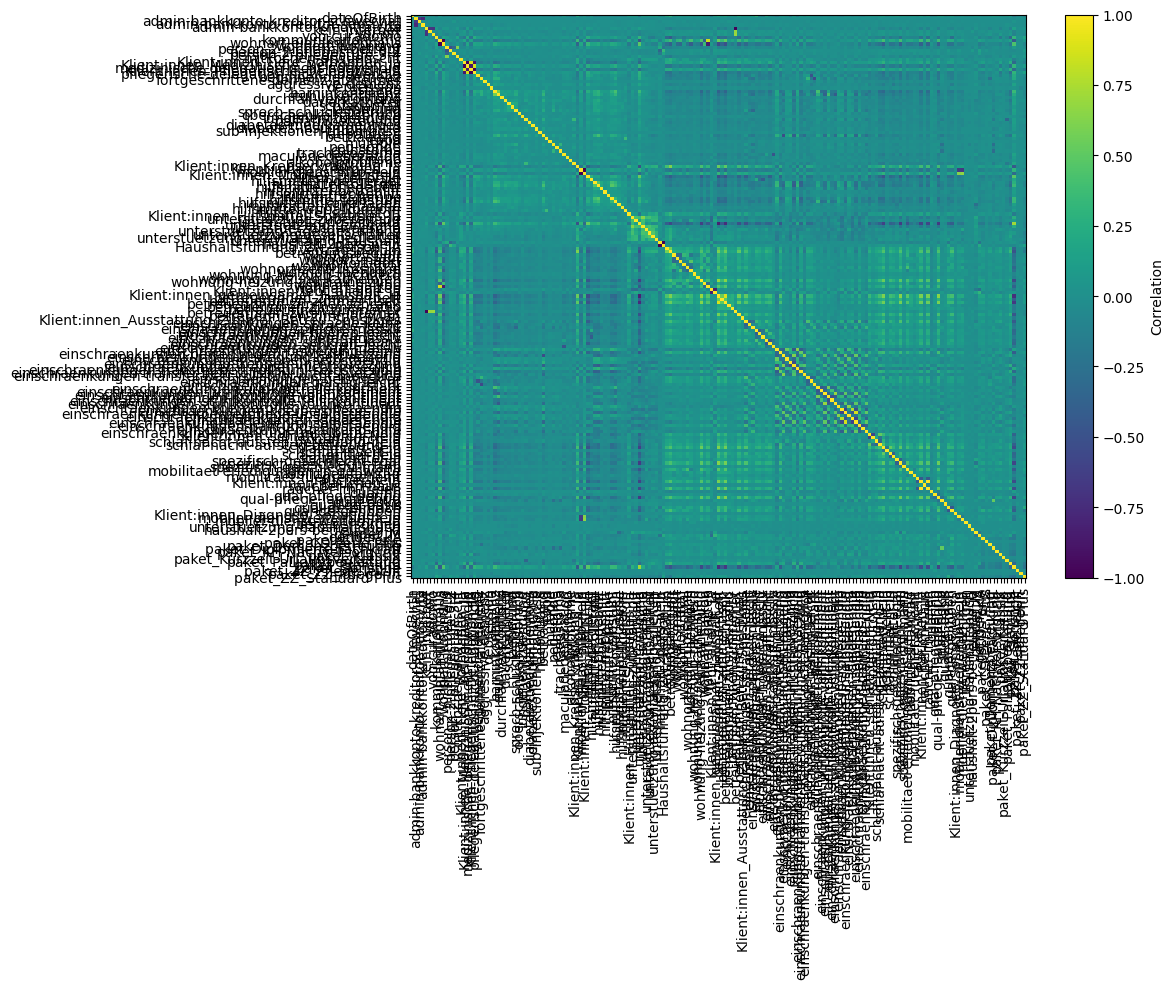

In [15]:
import matplotlib.pyplot as plt

corr = df.drop(columns=["id"]).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [16]:
def remove_correlated_features(df, threshold=0.8, exclude=["id"]):

    result = df.copy()
    dropped = []

    while True:

        features = result.drop(
            columns=exclude,
            errors="ignore"
        )

        corr = features.corr().abs()

        # Remove diagonal
        np.fill_diagonal(corr.values, 0)

        # Find strongest remaining correlation
        max_corr = corr.max().max()

        if max_corr <= threshold:
            break

        # Find the pair
        var1, var2 = corr.stack().idxmax()

        # Mean absolute correlation with all other variables
        score1 = corr.loc[var1].mean()
        score2 = corr.loc[var2].mean()

        # Drop the more redundant variable
        if score1 > score2:
            drop = var1
        else:
            drop = var2

        dropped.append({
            "dropped": drop,
            "var1": var1,
            "var2": var2,
            "pair_corr": max_corr,
            "score_var1": score1,
            "score_var2": score2
        })

        result = result.drop(columns=drop)

    return result, pd.DataFrame(dropped)

In [17]:
df_reduced, dropped = remove_correlated_features(
    df,
    threshold=0.7
)

print(dropped)

                                    dropped  \
0   pflegerische-delegation-nicht-notwendig   
1            Klient:innen_Mobiler_Dienst_JA   
2            Haushaltsführung_2te_Person_JA   
3   medizinische-delegation-nicht-notwendig   
4                           wohnart-wohnung   
5                   Klient:innen_Rauchen_Ja   
6                             kein-internet   
7                 betreuerinnen-zimmer-bett   
8   Klient:innen_Medizinische_Delegation_Ja   
9   einschraenkungen-kleiden-unselbstaendig   
10                  wohnart-einfamilienhaus   
11             Klient:innen_lebt_alleine_Ja   
12           einschraenkungen-kleiden-hilfe   
13       admin-bankkonto-kreditor-schwechat   
14                 unterstuetzung-reinigung   
15            betreuerinnen-zimmer-internet   

                                             var1  \
0         Klient:innen_Pflegerische_Delegation_JA   
1                         mobiler-dienst-hkp-nein   
2                             haushalt-2p

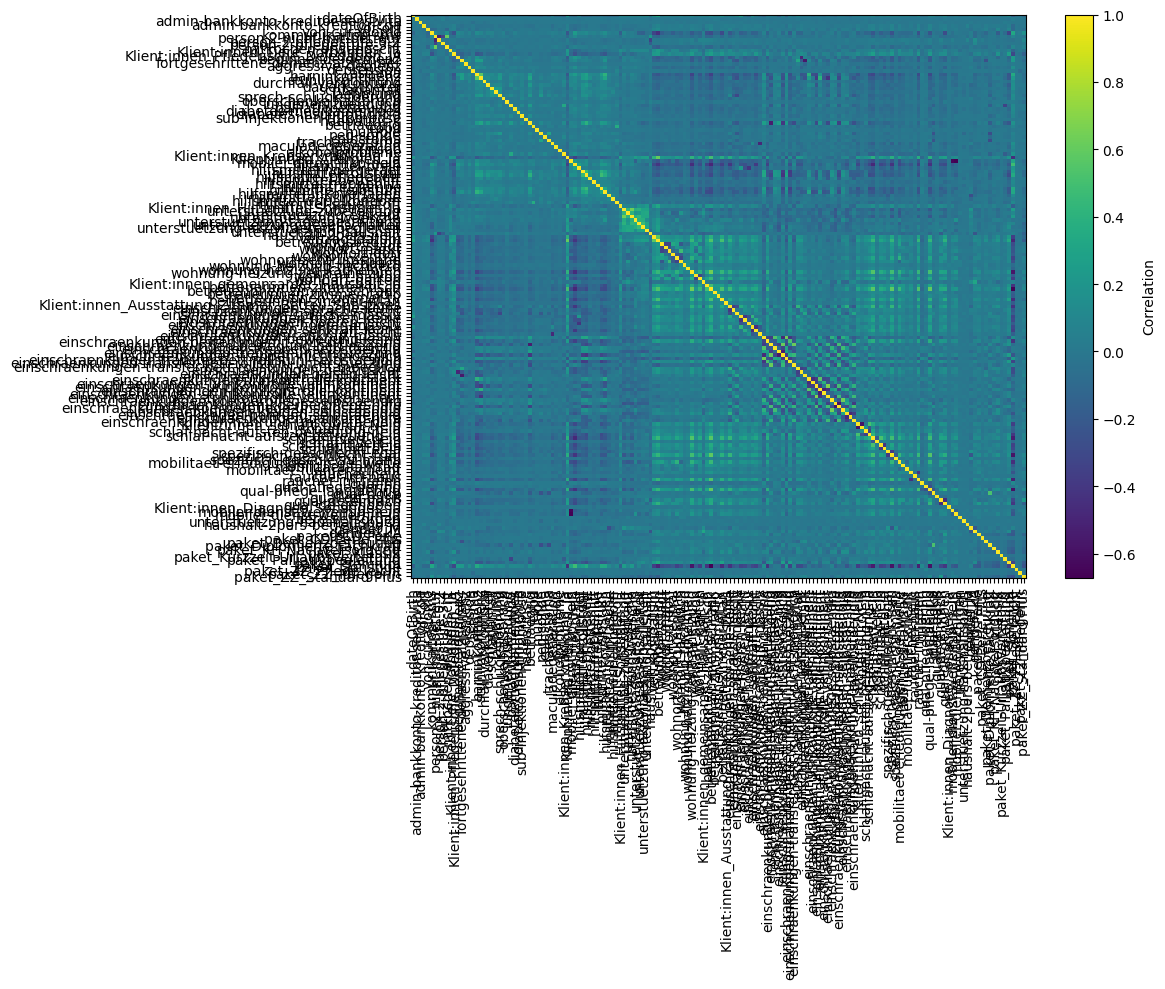

In [18]:
import matplotlib.pyplot as plt

corr = df_reduced.drop(columns=["id"]).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [19]:
import gower


X = df_reduced.drop(
    columns=["id"],
    errors="ignore"
).copy()

# Convert all numeric columns to float
numeric_cols = X.select_dtypes(include=np.number).columns
X[numeric_cols] = X[numeric_cols].astype(float)

bool_cols = X.select_dtypes(include=["bool", "boolean"]).columns
X[bool_cols] = X[bool_cols].astype(float)

distance_matrix = gower.gower_matrix(X)

In [20]:
def kmedoids_precomputed(
    distance_matrix,
    n_clusters,
    max_iter=100,
    random_state=42
):
    D = np.asarray(distance_matrix)

    n_samples = D.shape[0]

    if D.shape[0] != D.shape[1]:
        raise ValueError("distance_matrix must be square")

    rng = np.random.default_rng(random_state)

    # Random initial medoids
    medoid_indices = rng.choice(
        n_samples,
        size=n_clusters,
        replace=False
    )

    for _ in range(max_iter):

        # Assign every observation to nearest medoid
        labels = np.argmin(
            D[:, medoid_indices],
            axis=1
        )

        new_medoids = medoid_indices.copy()

        for cluster_id in range(n_clusters):

            cluster_indices = np.where(
                labels == cluster_id
            )[0]

            # Empty cluster protection
            if len(cluster_indices) == 0:
                continue

            # Distances among members of this cluster
            cluster_distances = D[
                np.ix_(
                    cluster_indices,
                    cluster_indices
                )
            ]

            # Point minimizing total within-cluster distance
            costs = cluster_distances.sum(axis=1)

            best_local_index = np.argmin(costs)

            new_medoids[cluster_id] = (
                cluster_indices[best_local_index]
            )

        # Stop if medoids no longer change
        if np.array_equal(
            np.sort(new_medoids),
            np.sort(medoid_indices)
        ):
            medoid_indices = new_medoids
            break

        medoid_indices = new_medoids

    # Final labels
    labels = np.argmin(
        D[:, medoid_indices],
        axis=1
    )

    # Equivalent idea to sklearn-extra inertia_
    inertia = np.sum(
        np.min(
            D[:, medoid_indices],
            axis=1
        )
    )

    return {
        "labels": labels,
        "medoid_indices": medoid_indices,
        "inertia": inertia
    }

In [21]:
models = {}

for k in range(2, 7):

    model = kmedoids_precomputed(
        distance_matrix,
        n_clusters=k,
        random_state=42
    )

    models[k] = {
        "model": model,
        "labels": model["labels"]
    }

In [22]:
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 7):

    model = kmedoids_precomputed(
        distance_matrix,
        n_clusters=k,
        random_state=42
    )

    labels = model["labels"]

    silhouette = silhouette_score(
        distance_matrix,
        labels,
        metric="precomputed"
    )

    results.append({
        "k": k,
        "silhouette": silhouette,
        "inertia": model["inertia"]
    })

results = pd.DataFrame(results)

print(results)

   k  silhouette      inertia
0  2    0.153227  1512.747314
1  3    0.136671  1467.040527
2  4    0.165231  1424.483887
3  5    0.156815  1411.984497
4  6    0.135935  1398.458618


In [23]:
best_k = results.loc[
    results["silhouette"].idxmax(),
    "k"
]

print("Best k:", best_k)

Best k: 4


In [26]:
df_clustered = df_reduced.copy()

df_clustered["cluster"] = models[best_k]["labels"]

In [29]:
df_clustered.value_counts("cluster")

cluster
1    3368
2    3090
0    1624
3     932
Name: count, dtype: int64

In [30]:
profile = (
    df_clustered.drop(columns=["id"])
    .groupby("cluster")
    .mean()
    .T
)

print(profile)

cluster                                        0             1             2  \
dateOfBirth                         1.939117e+07  1.935547e+07  1.938311e+07   
admin-bankkonto-kreditor-sensivita  6.157635e-04  5.938242e-04  6.472492e-04   
admin-bankkonto-kreditor-cda        1.231527e-03  1.187648e-03  3.236246e-04   
vor-ort                             3.756158e-02  6.532067e-03  3.106796e-02   
von-curadomo                        3.694581e-02  3.562945e-03  4.239482e-02   
...                                          ...           ...           ...   
paket_Premium                       2.272167e-01  3.444181e-02  3.087379e-01   
paket_Sonstige                      4.864532e-02  7.226841e-01  4.110032e-02   
paket_ZZ_Pflege leicht              0.000000e+00  1.781473e-03  3.236246e-04   
paket_ZZ_Pflegerin                  3.694581e-03  8.016627e-03  5.177994e-03   
paket_ZZ_Standard Plus              1.527094e-01  8.224466e-02  1.381877e-01   

cluster                                

In [31]:
df_clustered.to_csv("clients.csv", sep=";", index=False)